# Code for plots Fig. S2

In [7]:
# import libraries
import os,sys,inspect
import numpy as np
from scipy.stats import ttest_rel,wilcoxon
import matplotlib
matplotlib.use("Qt5Agg")
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline
import pandas as pd
from statsmodels.stats.anova import AnovaRM
from scipy.stats import friedmanchisquare
import warnings
warnings.filterwarnings("ignore")
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# import modules
currentdir = os.path.dirname(os.path.abspath(inspect.getfile(inspect.currentframe())))
parentdir = os.path.dirname(currentdir)
sys.path.insert(0,parentdir)
from data_import import Trial, Session
from behaviour import Psychometric_curves,get_performance_subject,get_stimuli_space
from utilities import format_boxplot, statistical_annotation, get_property,\
trainingpoint_short,trainingpoint_dict,normality_test,sphericity_test,\
format_axs,erf_psycho,get_experimental_timepoint,mle_fit_psycho

## Fig. 2A
### Decision plot and psychometric fit  for choices of example subject in generalization test 1 and in generalization test 2 

In [8]:
def real_predict_proba(input_values,known_metrics):
    sorted_metrics = list(known_metrics.items())
    values = list(known_metrics.keys())
    values.sort()
    probs = []
    for input_value in input_values:
        if input_value < values[0] or input_value > values[-1]:
            # If the input value is outside the range of known metrics
            if input_value < 0:
                lower_value, lower_prob = sorted_metrics[0]
                upper_value, upper_prob = sorted_metrics[1]
            else:
                lower_value, lower_prob = sorted_metrics[-2]
                upper_value, upper_prob = sorted_metrics[-1]
            slope = (upper_prob - lower_prob) / (upper_value - lower_value)
            intercept = lower_prob - slope * lower_value
            extrapolated_prob = slope * input_value + intercept
            probs.append(round(extrapolated_prob,4))
        else:
            # Find the two closest known input values
            for i in range(len(sorted_metrics) - 1):
                if sorted_metrics[i][0] <= input_value <= sorted_metrics[i + 1][0]:
                    # Interpolate probabilities
                    lower_value, lower_prob = sorted_metrics[i]
                    upper_value, upper_prob = sorted_metrics[i + 1]
                    ratio = (input_value - lower_value) / (upper_value - lower_value)
                    interpolated_prob = lower_prob + ratio * (upper_prob - lower_prob)
                    probs.append(round(interpolated_prob,4))
    
    return np.array(probs)


def get_dataset(test_stage):
    # returns dataset for artificial classifiers, training on training stage, and testing
    # for stimuli set in generalization tests
    if test_stage == 'gentest_1':
        train_stage = 'discrimination'
    elif test_stage == 'gentest_2':
        train_stage = 'categorization_4'
        
    stages = [train_stage,test_stage]
    Xs = []
    ys = []
    
    for stage in stages:
        mode,phase,categoryset_id = get_experimental_timepoint(stage)
        example_subject = 'BK4956_LR' # ground truth classification is the same for all subjects
        session_id = (Session()  \
                      & 'animal_id="%s"'%example_subject & 'mode="%s"'%mode \
                          & 'stage="%i"'%phase & 'categoryset_id="%i"'%categoryset_id).fetch('session_id')[-1]
        session_trials = Trial() \
            & 'animal_id="%s"'%example_subject & 'session_id="%i"'%session_id \
                & 'trialtype="active"'
                
        experiment = session_trials.fetch('name')[0]
        port_layout = session_trials.fetch('port_layout')[0]
        
        stimulus_id = list(session_trials.fetch('stimulus_id'))
        stimuli = [int(stimulus) for stimulus in stimulus_id]

        # get total stimuli space in experiment
        stimuli_space = get_stimuli_space(experiment)
        # normalize and log scale
        m = np.mean(np.log(stimuli_space))
        s = np.std(np.log(stimuli_space))
        norm_log_space = list((np.log(stimuli_space)-m)/s)
        stimuli_space = list(stimuli_space)
        # get stimuli set in stage(phase) in log norm scale
        X = np.array([norm_log_space[stimuli_space.index(stim)] for stim in stimuli])
        
        # get corresponding category assigned
        baited_port = session_trials.fetch('baited_port')
        y = [] 
        for i,stim in enumerate(stimuli):
            c = baited_port[i]
            # account for port layout - randomized across subjects
            if port_layout:
                c = 1-c
            y.append(c)
        
        Xs.append(X)
        ys.append(y)
        
    X_train, X_test = Xs
    y_train, y_test = ys
    return X_train, X_test, y_train, y_test


def get_groundtruth(stage):
    # get ground truth of stimuli (in log norm scale) in certain stage and corresponding category
    mode,phase,categoryset_id = get_experimental_timepoint(stage)
    # extract dataset 
    example_subject = 'BK4956_LR' # ground truth is the same for all animal subjects 
    session_id = (Session()  \
        & 'animal_id="%s"'%example_subject & 'mode="%s"'%mode \
            & 'stage="%i"'%phase & 'categoryset_id="%i"'%categoryset_id).fetch('session_id')[-1]
    session_trials = Trial() \
        & 'animal_id="%s"'%example_subject & 'session_id="%i"'%session_id \
            & 'trialtype="active"'
    
    experiment = session_trials.fetch('name')[0]
    port_layout = session_trials.fetch('port_layout')[0]
    
    stimulus_id = list(session_trials.fetch('stimulus_id'))
    stimuli = [int(stimulus) for stimulus in list(dict.fromkeys(stimulus_id))]
    stimuli.sort()
    # get total stimuli space in experiment
    stimuli_space = get_stimuli_space(experiment)
    # normalize and log scale
    m = np.mean(np.log(stimuli_space))
    s = np.std(np.log(stimuli_space))
    norm_log_space = list((np.log(stimuli_space)-m)/s)
    stimuli_space = list(stimuli_space)
    # get stimuli set in stage(phase) in log norm scale
    X = np.array([norm_log_space[stimuli_space.index(stim)] for stim in stimuli])
    
    # get corresponding category assigned
    baited_port = session_trials.fetch('baited_port')
    y = [] 
    for stim in stimuli:
        c = baited_port[stimulus_id.index(str(stim))]
        # account for port layout - randomized across subjects
        if port_layout:
            c = 1-c
        y.append(c)
        
    return X,y

def plot_decision_boundary(pred_func,axs,X):
    # Set min and max values and give it some padding
    x_min, x_max = X.min() - .5, X.max() + .5
    h = 0.01
    # Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(x_min, x_max, h))
    # Predict the function value for the whole grid
    Z = pred_func(xx[0])
    # Z = pred_func(xx[0].reshape(-1,1))
    # # print('Z.shape',Z)
    # Z = Z[:,1]
    
    Z = np.tile(Z, len(xx)).reshape(len(xx),len(xx))

    axs.contourf(xx, yy, Z, cmap=plt.cm.RdBu,vmin=0,vmax=1)
    return axs

def plot_classifier_heatmap(dataset,metrics,data,score):
   
    X, y = dataset # log norm stimuli (x) , corresponding assigned category (y)
    
    x_min, x_max = X.min() - 0.5, X.max() + 0.5
    y_min, y_max = X.min() - 0.5, X.max() + 0.5
    y_plot = -0.25 
    
    cm_bright = ListedColormap(["tab:red","tab:blue"])
    
    pred_func = lambda x: real_predict_proba(x,metrics)
    
    # plot decision boundary according to metrics given
    fig,ax = plt.subplots()
    fig.set_figwidth(2.8)
    fig.set_figheight(4)
    plot_decision_boundary(pred_func,ax,X)
    
    # Plot the testing points
    ax.scatter(
        X,
        [y_plot] * len(X),
        c=y,
        cmap=cm_bright,
        edgecolors="white",
        s=64,
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(())
    ax.set_yticks(())
    #ax.set_title(plot_title,fontsize=14)
    ax.text(
        x_max - 2,
        y_min + 0.3,
        ("%.2f"%score + '$\%$').lstrip("0"),
        size=16,
        horizontalalignment="left",
        color='black',
    )
    print('score', score)

    # add the psychometrics 
    if data is not None:
        data,pars = data
        x, y = -2,0.2 # Bottom-left corner coordinates
        width, height = 1.9, 3 # Width and height of the box
        white_box = Rectangle((x, y), width, height, fill=True, color='white', edgecolor='white', linewidth=1)
        # Add the white box to the plot
        ax.add_patch(white_box)
        l, b, h, w = 0.2, 0.65, 0.2, 0.25 # Position and size of the small subplot
        ax2 = fig.add_axes([l, b, h, w], facecolor='white')
        
        # Plot on the small subplot
        ax2.plot(data[0], data[2], 'ko', mfc='k',markersize=3)
        ax2.axvline(x=0,linestyle='--',color='black',alpha=0.5)
        ax2.axhline(y=0.5,linestyle='--',color='black',alpha=0.5)
        ax2.set_ylim(0,1)
        ax2.plot(np.arange(data[0][0]-0.1, data[0][-1]+0.2, 0.1), 
                  erf_psycho(pars, np.arange(data[0][0]-0.1, data[0][-1]+0.2, 0.1)),'-k')

    plt.tight_layout()
    plt.show()
        

def plot_psychometric_map(animal_id,stage):
    
    psy_entry = Psychometric_curves() \
          & 'experimental_timepoint="%s"'%stage \
               & 'animal_id="%s"'%animal_id
    data = psy_entry.fetch('data')[0]
    pars = psy_entry.fetch('parameters')[0]
    
    metrics = {round(data[0][i],2):data[2][i] for i in range(len(data[0]))}
    

    performance = get_performance_subject(stage,animal_id)
    
    dataset = get_groundtruth(stage)
    
    data = data, pars
    plot_classifier_heatmap(dataset,metrics,data,performance)
    

score 84.04


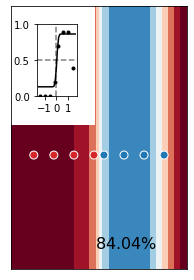

In [9]:
plot_psychometric_map('BK4956_LR',stage='gentest_1')

score 64.84


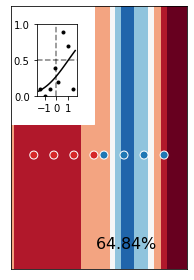

In [10]:
plot_psychometric_map('BK4956_LR',stage='gentest_2')

score 65.52


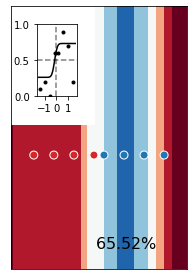

In [11]:
plot_psychometric_map('BK4933_LR',stage='gentest_1')

score 73.68


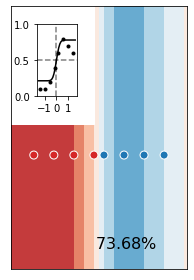

In [12]:
plot_psychometric_map('BK4933_LR',stage='gentest_2')

score 65.91


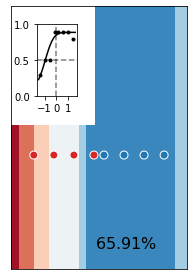

In [13]:
plot_psychometric_map('BK4937_R',stage='gentest_1')

score 67.135


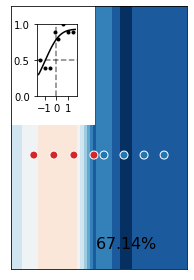

In [14]:
plot_psychometric_map('BK4937_R',stage='gentest_2')

score 71.88


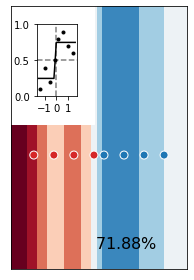

In [15]:
plot_psychometric_map('BK4947_R',stage='gentest_1')

score 71.11


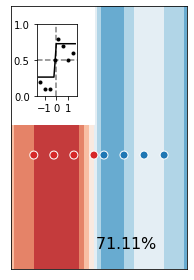

In [16]:
plot_psychometric_map('BK4947_R',stage='gentest_2')

score 64.2


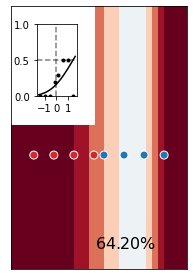

In [17]:
plot_psychometric_map('BK4936_L',stage='gentest_1')

score 75.82


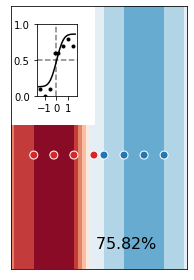

In [18]:
plot_psychometric_map('BK4936_L',stage='gentest_2')

score 67.42


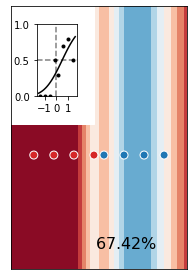

In [19]:
plot_psychometric_map('BK4926_L',stage='gentest_1')

score 68.89


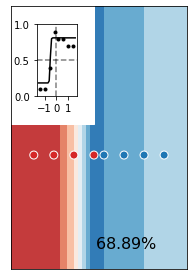

In [20]:
plot_psychometric_map('BK4926_L',stage='gentest_2')

## Fig. 2B
###  Example decision plots and psychometric fits for artificial classifiers 

Nearest Neighbors
score 100.0


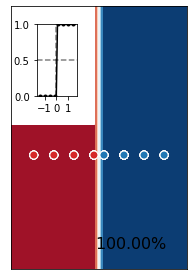

Linear SVM
score 92.05033958605443


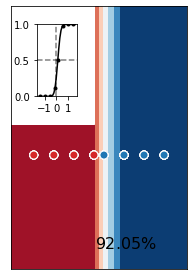

Poly SVM
score 87.24533250285742


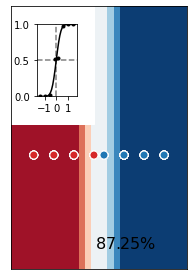

Neural Net
score 90.1613903631111


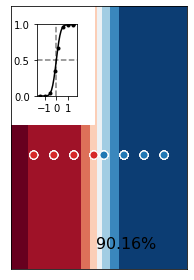

Decision Tree
score 100.0


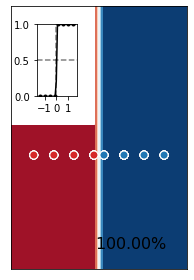

Naive Bayes
score 100.0


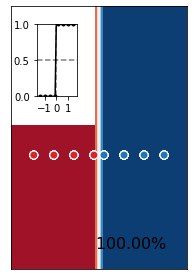

In [21]:
names = [
    "Nearest Neighbors",
    "Linear SVM",
    "Poly SVM",
    "Neural Net",
    "Decision Tree",
    "Naive Bayes",
]
classifiers = [
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025, random_state=42, probability=True),
    SVC(kernel="poly", C=0.025, random_state=42, probability=True),
    MLPClassifier(alpha=1, max_iter=1000, random_state=42),
    DecisionTreeClassifier(max_depth=5, random_state=42),
    GaussianNB(),
]

X_train,X_test, y_train, y_test = get_dataset('gentest_1')
X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)


for name, clf in zip(names, classifiers):
    print(name)
    clf.fit(X_train, y_train)
    pred_func = lambda x: clf.predict_proba(x)
    
    datax = np.unique(X_test) 
    datay = clf.predict_proba(np.unique(X_test).reshape(-1,1))[:,1]
    performance = []
    for test_0 in datay[:4]:
        performance.append(1-test_0)
    performance += list(datay[4:])
    score = np.mean(performance)*100
    
    nn = np.full((len(datax),), 10)
    data = np.vstack((datax, nn, datay))
    
    pars,_ = mle_fit_psycho(data, 'erf_psycho')
    
    metrics = {round(data[0][i],2):data[2][i] for i in range(len(data[0]))}
    
    plot_classifier_heatmap((X_test, y_test),metrics,(data,pars),score)

## Fig. 2C
Corresponds to schematic illustrations of choice probability for rule vs feature-based generalization